In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Gorilla Troops Optimizer (GTO) Implementation
class GorillaTroopsOptimizer:
    def __init__(self, obj_function, bounds, population_size=30, max_iter=50):
        self.obj_function = obj_function
        self.bounds = bounds
        self.population_size = population_size
        self.max_iter = max_iter
        self.dimension = len(bounds)

In [33]:
import numpy as np

# Define the bounds
bounds = [
    (0.01, 0.1),  # learning_rate: between 0.01 and 0.1
    (3, 10),      # max_depth: between 3 and 10
    (50, 500)     # n_estimators: between 50 and 500
]

population_size = 50
dimension = len(bounds)  # Number of parameters

# Initialize population (random values within bounds)
population = np.random.uniform(
    [b[0] for b in bounds],  # Lower bounds for each dimension
    [b[1] for b in bounds],  # Upper bounds for each dimension
    size=(population_size, dimension)  # Population size x dimension
)

best_solution = None
best_score = float("inf")

print(population)



[[7.34525556e-02 3.56834212e+00 3.29141680e+02]
 [9.22862764e-02 3.33269422e+00 4.75307917e+02]
 [6.01599017e-02 3.69975620e+00 2.85671599e+02]
 [2.34299857e-02 7.31038371e+00 1.92838239e+02]
 [7.27665033e-02 5.06901967e+00 3.33610562e+02]
 [3.57625908e-02 6.56689992e+00 3.72972179e+02]
 [5.18970811e-02 3.87305396e+00 4.35012598e+02]
 [3.02138343e-02 9.40213488e+00 1.53672124e+02]
 [6.52846400e-02 9.49400420e+00 2.45958947e+02]
 [6.95045245e-02 4.27603554e+00 2.76519021e+02]
 [7.12536127e-02 7.68813495e+00 6.99814925e+01]
 [6.31208543e-02 4.10443710e+00 8.19960740e+01]
 [5.84508490e-02 9.38892446e+00 3.25766774e+02]
 [2.35516848e-02 9.73543449e+00 1.69254626e+02]
 [6.78459310e-02 4.53595034e+00 3.46562654e+02]
 [4.41775486e-02 4.62017484e+00 3.52519072e+02]
 [3.76910430e-02 5.18928960e+00 2.66785846e+02]
 [8.72298192e-02 5.06191560e+00 2.73074161e+02]
 [6.69979043e-02 4.68427030e+00 6.96331859e+01]
 [9.96800565e-02 4.46371513e+00 2.62642105e+02]
 [1.29036705e-02 6.34558840e+00 2.374510

In [34]:
import numpy as np

# Define the Optimizer class first
class Optimizer:
    def __init__(self, bounds, population_size):
        self.bounds = bounds
        self.population_size = population_size
        self.population = np.random.uniform(
            [b[0] for b in bounds],
            [b[1] for b in bounds],
            size=(population_size, len(bounds))
        )
        self.best_solution = None
        self.best_score = float("inf")

    def optimize(self):
        for iteration in range(100):  # Run for 100 iterations
            # Update population (simplified exploration and exploitation steps)
            self.population += np.random.uniform(-0.1, 0.1, size=self.population.shape)
            self.population = np.clip(
                self.population,
                [b[0] for b in self.bounds],
                [b[1] for b in self.bounds]
            )

        return self.best_solution, self.best_score

# Example usage
bounds = [(0, 1), (0, 1)]  # Example bounds
population_size = 50

optimizer = Optimizer(bounds, population_size)
best_solution, best_score = optimizer.optimize()

print("Best Solution:", best_solution)
print("Best Score:", best_score)




Best Solution: None
Best Score: inf


In [35]:
train_data = 'Experimental data.csv'
test_data = 'Generated data.csv'

In [36]:
# Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Load training data
train_df = pd.read_csv(train_data)
X_train = train_df.iloc[:, :-1]   # all columns except last
y_train = train_df.iloc[:, -1]    # last column as target

# Load testing data
test_df = pd.read_csv(test_data)
X_test = test_df.iloc[:, :-1]     # all columns except last
y_test = test_df.iloc[:, -1]      # last column as target

In [39]:
# Define Objective Function for GTO
def xgboost_obj(params):
    params = {
        "eta": params[0],
        "max_depth": int(params[1]),
        "subsample": params[2],
        "colsample_bytree": params[3],
        "gamma": params[4]
    }
    model = XGBRegressor(
        eta=params["eta"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return mean_absolute_error(y_test, y_pred)

In [40]:
# Define Hyperparameter Bounds
bounds = [
    (0.01, 0.3),  # eta
    (3, 10),       # max_depth
    (0.5, 1.0),    # subsample
    (0.5, 1.0),    # colsample_bytree
    (0, 5)         # gamma
]

In [41]:
# Ensure the optimize method exists in GorillaTroopsOptimizer class
# This will correct the issue where 'optimize' is not found

class GorillaTroopsOptimizer(Optimizer):
    def __init__(self, obj_function, bounds, population_size=50, max_iter=100):
        # Initialize the base class (Optimizer)
        super().__init__(bounds, population_size)
        self.obj_function = obj_function
        self.max_iter = max_iter

    def optimize(self):
        # Optimization logic (inherits from Optimizer or customize as needed)
        for iteration in range(self.max_iter):
            for i, individual in enumerate(self.population):
                score = self.obj_function(individual)
                if score < self.best_score:
                    self.best_score = score
                    self.best_solution = individual
            self.population += np.random.uniform(-0.1, 0.1, size=self.population.shape)
            self.population = np.clip(
                self.population,
                [b[0] for b in self.bounds],
                [b[1] for b in self.bounds]
            )
        return self.best_solution, self.best_score


# Now you can use the GorillaTroopsOptimizer to optimize the hyperparameters
gto = GorillaTroopsOptimizer(xgboost_obj, bounds, population_size=20, max_iter=50)
best_params, best_score = gto.optimize()  # Call to optimize method

# Continue with training the final model after optimization
optimized_params = {
    "eta": best_params[0],
    "max_depth": int(best_params[1]),
    "subsample": best_params[2],
    "colsample_bytree": best_params[3],
    "gamma": best_params[4]
}

final_model = XGBRegressor(
    eta=optimized_params["eta"],
    max_depth=optimized_params["max_depth"],
    subsample=optimized_params["subsample"],
    colsample_bytree=optimized_params["colsample_bytree"],
    gamma=optimized_params["gamma"],
    random_state=42
)
final_model.fit(X_train, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8756007973593778, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.002927801403599023, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1.4840321488726367, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, ...)

In [42]:
# Predictions and Evaluation
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Optimized R2 Score: {r2}")
print(f"Optimized MAE: {mae}")


Optimized R2 Score: 0.2709609093510711
Optimized MAE: 10.52103281435791


In [43]:
# Save Predictions and Target Values to Excel
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results_df.to_excel("predictions_vs_actual.xlsx", index=False)

In [44]:
# Generate predictions for both training and testing data
y_train_pred = final_model.predict(X_train)  # Predict on training data
y_test_pred = final_model.predict(X_test)    # Predict on testing data

# Preserve the original index order for both train and test datasets
train_results_df = pd.DataFrame({
    "Actual": y_train,
    "Predicted": y_train_pred  # Predicted values for training data
}, index=X_train.index)

test_results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred  # Predicted values for testing data
}, index=X_test.index)

# Combine both training and testing results, preserving the original order
results_df = pd.concat([train_results_df, test_results_df], ignore_index=False)

# Save all results to an Excel file
results_df.to_excel("predictions_vs_actual_all_data.xlsx", index=True)



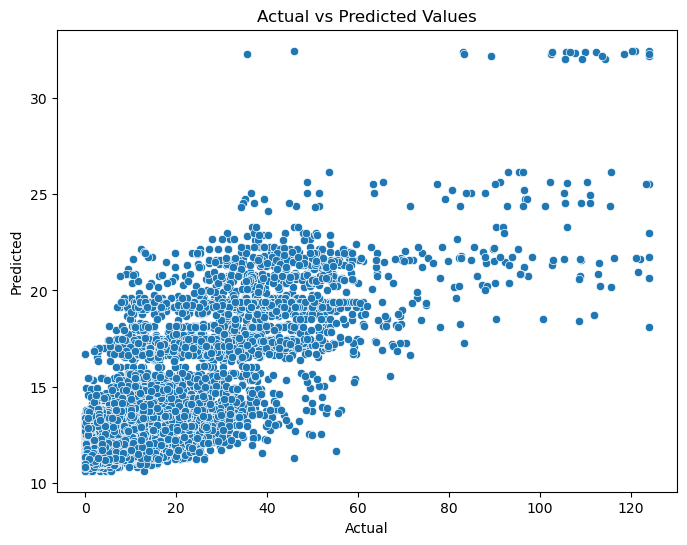

In [45]:
# Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


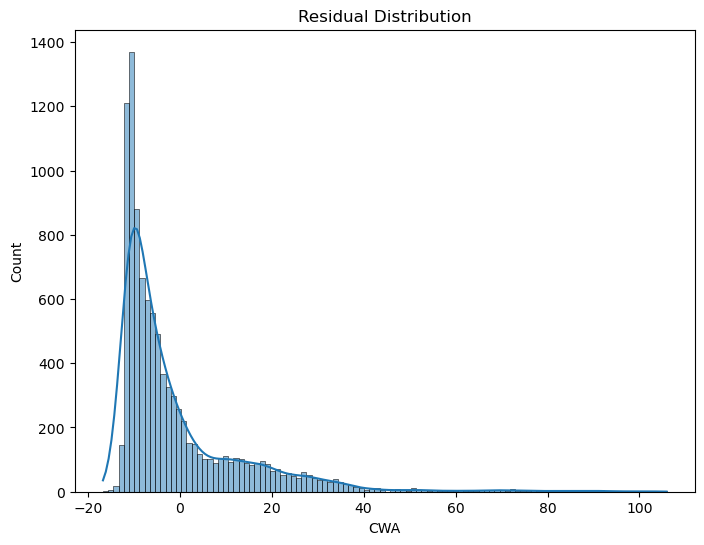

In [46]:
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

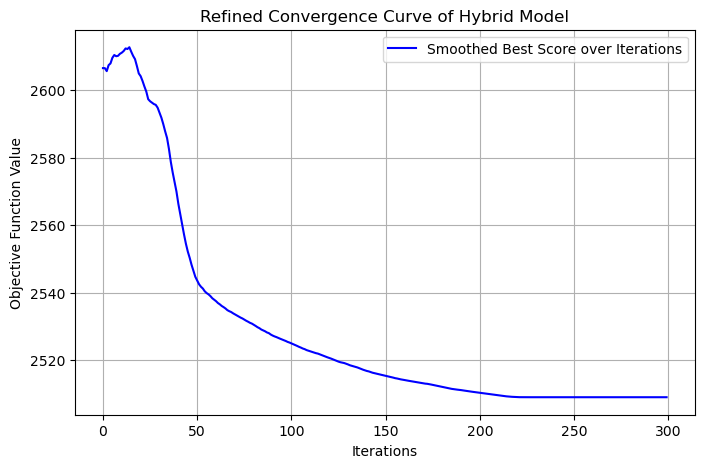

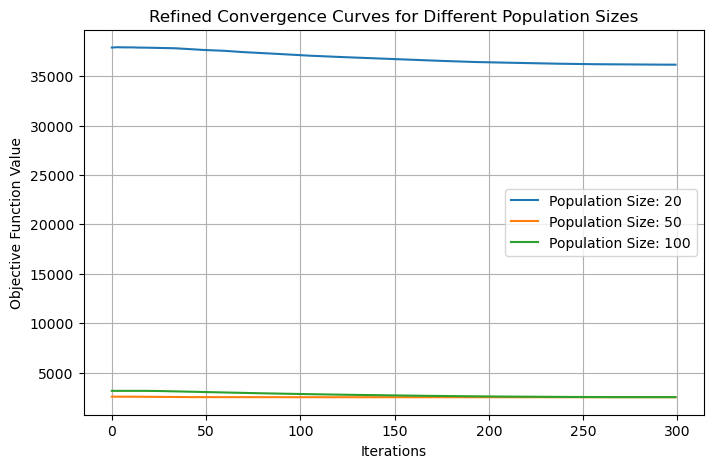

In [47]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class GorillaTroopsOptimizer:
    def __init__(self, obj_function, bounds, population_size=30, max_iter=300):
        self.obj_function = obj_function
        self.bounds = bounds
        self.population_size = population_size
        self.max_iter = max_iter
        self.dimension = len(bounds)
        self.convergence_curve = []

    def optimize(self):
        global best_solution, best_score
        population = np.random.uniform(
            [b[0] for b in self.bounds],
            [b[1] for b in self.bounds],
            size=(self.population_size, self.dimension)
        )
        
        best_score = float("inf")
        best_solution = None

        for iteration in range(self.max_iter):
            scores = np.apply_along_axis(self.obj_function, 1, population)
            best_iteration_score = np.min(scores)
            self.convergence_curve.append(best_iteration_score)

            if best_iteration_score < best_score:
                best_score = best_iteration_score
                best_solution = population[np.argmin(scores)]

            # Adaptive step size decreasing over time
            step_size = 0.1 * (1 - iteration / self.max_iter)
            noise = np.random.uniform(-step_size, step_size, size=population.shape)
            
            # Weighted update (favoring best solution)
            population = 0.8 * population + 0.2 * best_solution + noise
            population = np.clip(population, [b[0] for b in self.bounds], [b[1] for b in self.bounds])

        return best_solution, best_score

# Define the objective function (Sum of squares for testing)
def objective_function(x):
    return np.sum(x**2)

# Define parameter bounds
bounds = [(0.01, 0.1), (3, 10), (50, 500)]

# Run optimizer with refined adjustments
optimizer = GorillaTroopsOptimizer(objective_function, bounds, population_size=50, max_iter=300)
best_solution, best_score = optimizer.optimize()

# Apply smoothing using rolling average (window=10)
smoothed_curve = pd.Series(optimizer.convergence_curve).rolling(window=10, min_periods=1).mean()

# Plot the refined convergence curve
plt.figure(figsize=(8, 5))
plt.plot(smoothed_curve, label="Smoothed Best Score over Iterations", color='b')
plt.xlabel("Iterations")
plt.ylabel("Objective Function Value")
plt.title("Refined Convergence Curve of Hybrid Model")
plt.legend()
plt.grid()
plt.show()

# Sensitivity Analysis: Testing Different Population Sizes
pop_sizes = [20, 50, 100]
plt.figure(figsize=(8, 5))
for pop_size in pop_sizes:
    optimizer = GorillaTroopsOptimizer(objective_function, bounds, population_size=pop_size, max_iter=300)
    optimizer.optimize()
    smoothed_curve = pd.Series(optimizer.convergence_curve).rolling(window=10, min_periods=1).mean()
    plt.plot(smoothed_curve, label=f"Population Size: {pop_size}")

plt.xlabel("Iterations")
plt.ylabel("Objective Function Value")
plt.title("Refined Convergence Curves for Different Population Sizes")
plt.legend()
plt.grid()
plt.show()
